# Netflix Data Analysis Project
By: ARADHANA AK

## Objective
To analyse Netflix content data and find patterns in movies, TV shows, countries, genres and ratings.

## Dataset
8807 Netflix titles with 12 columns including title, type, country, genre, rating and date added.

In [32]:
with zipfile.ZipFile('/content/drive/MyDrive/archive (1) (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

df = pd.read_csv('/content/netflix_titles.csv')
print(df.shape)

(8807, 12)


In [33]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


## Data Understanding

In [34]:
print(df.columns)
print(df.dtypes)
df.head()

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning

In [35]:
print("Missing values:")
print(df.isnull().sum())
df['director'].fillna('Unkown',inplace=True)

df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

print("\nAfter cleaning:")
print(df.isnull().sum())

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

After cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      98
dtype: int64


/tmp/ipykernel_757/3353323484.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unkown',inplace=True)
/tmp/ipykernel_757/3353323484.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

## Analysis and Visualisation
### Question 1: Movies vs TV Shows

/tmp/ipykernel_757/2590926889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='type',palette='Set1')


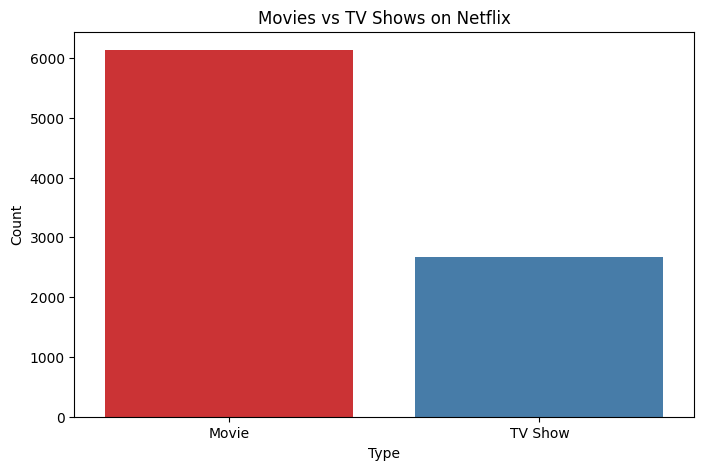

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='type',palette='Set1')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

**Finding 1:** Netflix has 6131 Movies and 2676 TV Shows.
# Movies make up 70% of all Netflix content.

### Question 2: Which country produces most content?

/tmp/ipykernel_757/4241236491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,y=top_countries.index,palette='coolwarm')


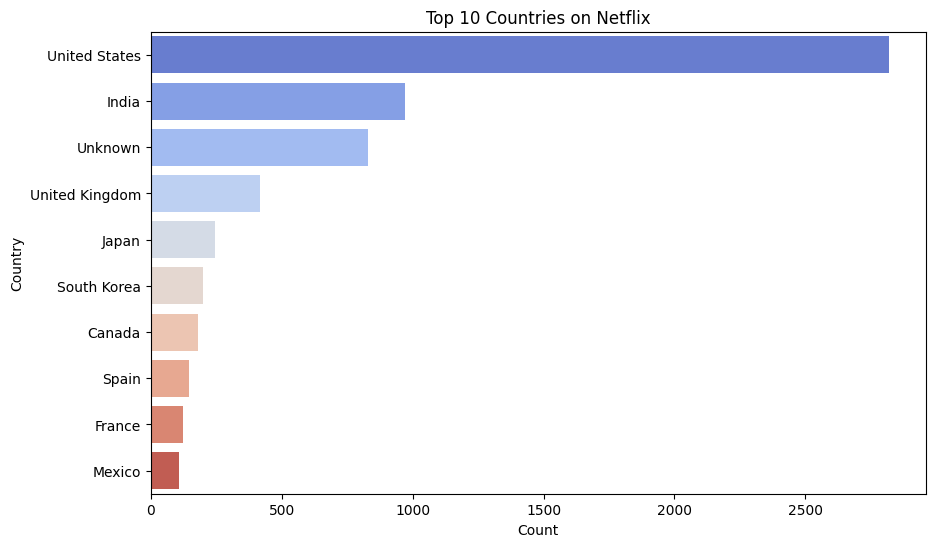

In [39]:
top_countries = df['country'].value_counts()[:10]
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values,y=top_countries.index,palette='coolwarm')
plt.title('Top 10 Countries on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

**Finding 2:** USA dominates Netflix with 2800+ titles.
India is 2nd with 1000+ titles. UK and Japan follow.

### Question 3: Which year had most content added?

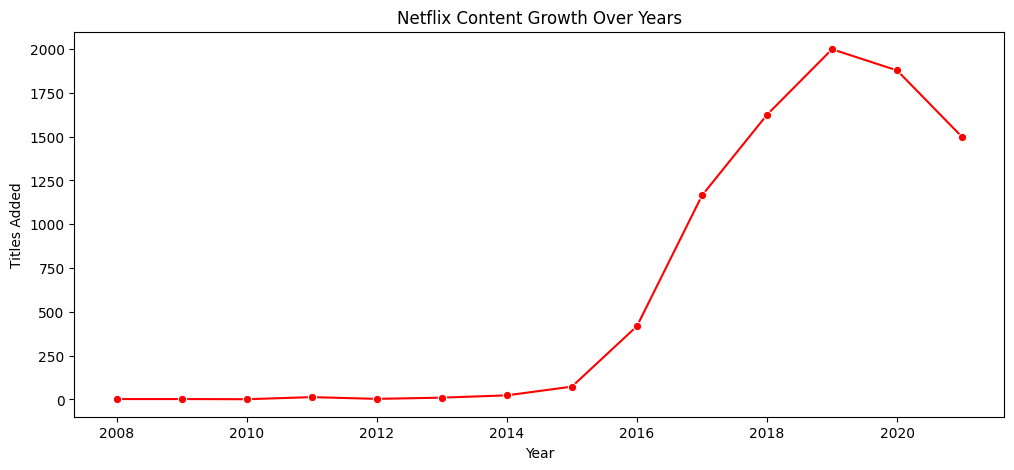

In [40]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(12,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='red')
plt.title('Netflix Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()

**Finding 3:** Netflix had very little content before 2015.
It grew rapidly and peaked in 2019 with 2000+ titles.
Dropped slightly in 2020-2021 due to COVID.


### Question 4: What are the top 10 genres?

/tmp/ipykernel_757/1845862618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


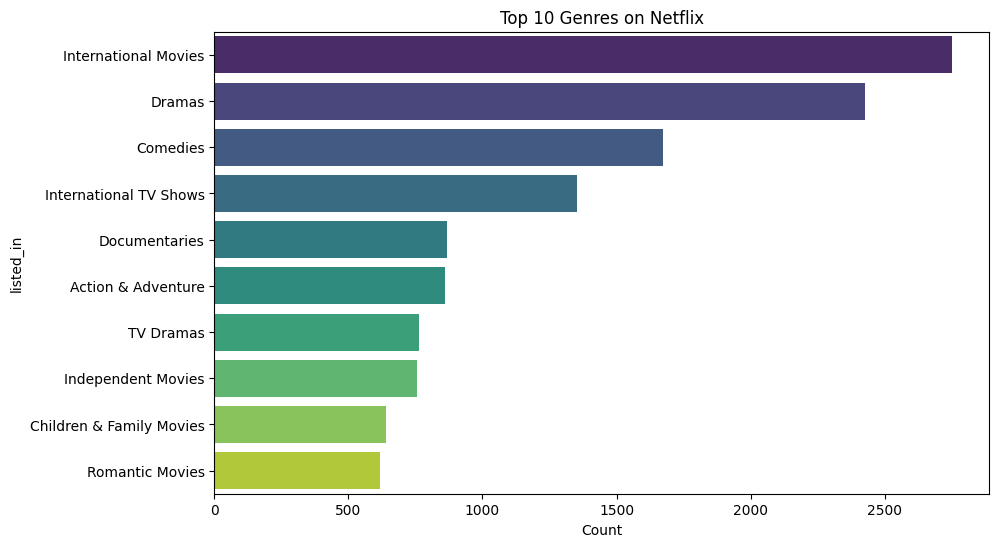

In [41]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts()[:10]
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.show()

**Finding 4:** International Movies is the most popular genre
with 2800+ titles. Dramas and Comedies follow closely.

### Question 5: Which rating has most content?

/tmp/ipykernel_757/3012515877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating',


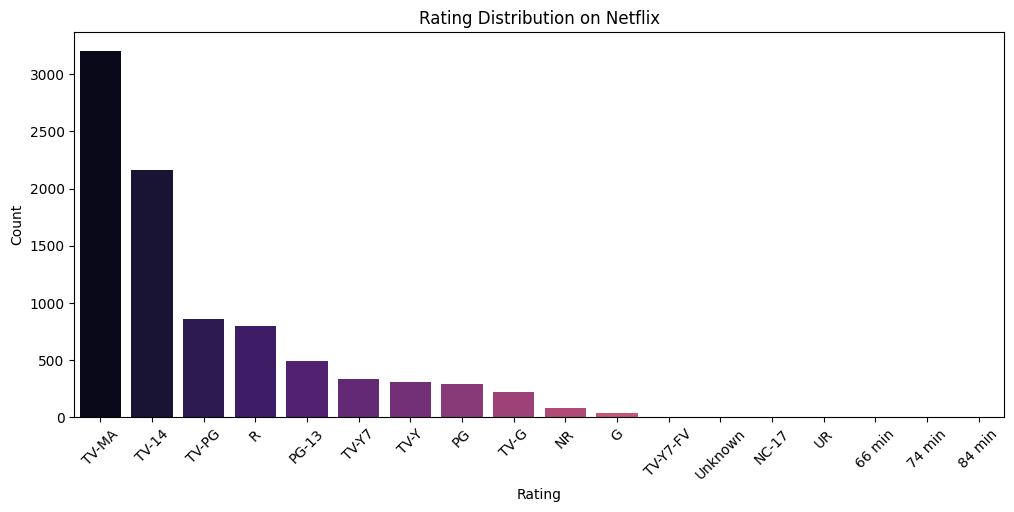

In [42]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='rating',
              order=df['rating'].value_counts().index,
              palette='magma')
plt.title('Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Finding 5:** TV-MA (Mature Audiences) dominates with 3000+ titles.
Netflix clearly targets adult audiences.

## Conclusions

1. Netflix has 70% Movies and 30% TV Shows
2. USA produces most content — India is a strong 2nd
3. Netflix grew rapidly from 2015 and peaked in 2019
4. International Movies is the most popular genre
5. Netflix primarily targets adult audiences (TV-MA)

## Tools Used
- Python, Pandas, Seaborn, Matplotlib
- Dataset: Netflix Titles (Kaggle)